# Kapitel 1: Die Daten entdecken

## Kann eine Maschine Emotionen lesen?

Jeden Tag schreiben Millionen von Menschen Bewertungen auf Amazon.
In jedem dieser Texte steckt eine Emotion: Begeisterung, Enttäuschung, Wut oder Freude.

Unser Ziel: **Eine Maschine soll lernen, diese Emotionen automatisch zu erkennen.**

Doch bevor wir ein Modell trainieren können, müssen wir verstehen, womit wir arbeiten.
Dieses Notebook ist der erste Schritt — wir öffnen den Datensatz und schauen hinein.

## 1.1 SparkSession starten

Apache Spark ist unser Werkzeug für die Verarbeitung großer Datenmengen.
Anders als Pandas kann Spark Millionen von Zeilen effizient verarbeiten,
indem es die Arbeit auf mehrere Prozessorkerne verteilt.

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AmazonReviews – Daten laden") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark Version:", spark.version)
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/20 16:46:50 WARN Utils: Your hostname, Alper-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.3 instead (on interface en0)
26/03/20 16:46:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/20 16:46:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 4.1.1


## 1.2 Der erste Blick auf die Daten

Unser Datensatz stammt von Kaggle und enthält Amazon-Kundenbewertungen.
Die CSV-Datei hat **keinen Header** — wir vergeben die Spaltennamen manuell:

- **Score** — Sentiment-Label (1 = negativ, 2 = positiv)
- **Summary** — Kurztitel der Bewertung
- **Text** — Der vollständige Bewertungstext

Eine wichtige Erkenntnis: Die Scores sind **keine Sternebewertungen (1–5)**,
sondern bereits vorkategorisierte Sentiment-Labels. Das vereinfacht unsere spätere Arbeit.

In [2]:
# CSV einlesen (OHNE Header)
df_raw = spark.read.csv(
    "/Users/alperbildiren/PYSPARK_AMAZON_PROJECT/data/test.csv",
    header=False,
    inferSchema=True,
    multiLine=True,
    escape='"'
)

# Spalten umbenennen
df_raw = df_raw.toDF("Score", "Summary", "Text")

print(f"Datensatz erfolgreich geladen: {df_raw.count():,} Zeilen, {len(df_raw.columns)} Spalten")
print(f"Spalten: {df_raw.columns}")

Datensatz erfolgreich geladen: 400,000 Zeilen, 3 Spalten
Spalten: ['Score', 'Summary', 'Text']


### Was sehen wir?

400.000 Bewertungen — das ist viermal mehr als die Mindestanforderung von 100.000.
Schauen wir uns die Struktur genauer an.

In [3]:
df_raw.printSchema()

root
 |-- Score: integer (nullable = true)
 |-- Summary: string (nullable = true)
 |-- Text: string (nullable = true)



In [4]:
df_raw.show(5, truncate=80)

+-----+------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|Score|                                                                 Summary|                                                                            Text|
+-----+------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|    2|                                                                Great CD|My lovely Pat has one of the GREAT voices of her generation. I have listened ...|
|    2|One of the best game music soundtracks - for a game I didn't really play|Despite the fact that I have only played a small portion of the game, the mus...|
|    1|                                        Batteries died within a year ...|I bought this charger in Jul 2003 and it worked OK for a while. The design is...|
|    2|                     

In [5]:
df_raw.limit(5).toPandas()

,Score,Summary,Text
0,2,Great CD,My lovely Pat has one of the GREAT voices of h...
1,2,One of the best game music soundtracks - for a...,Despite the fact that I have only played a sma...
2,1,Batteries died within a year ...,I bought this charger in Jul 2003 and it worke...
3,2,"works fine, but Maha Energy is better",Check out Maha Energy's website. Their Powerex...
4,2,Great for the non-audiophile,Reviewed quite a bit of the combo players and ...


## 1.3 Datenqualität: Gibt es Lücken?

Bevor wir weitermachen, müssen wir wissen: **Fehlen Daten?**
Fehlende Werte könnten unsere Analyse verfälschen.

In [6]:
# Statistiken für die Score-Spalte
df_raw.select("Score").summary("count", "min", "max", "mean", "stddev").show()

+-------+------------------+
|summary|             Score|
+-------+------------------+
|  count|            400000|
|    min|                 1|
|    max|                 2|
|   mean|               1.5|
| stddev|0.5000006250011726|
+-------+------------------+



In [7]:
from pyspark.sql.functions import col, count, when, round as spark_round

total_rows = df_raw.count()

null_counts = df_raw.select(
    [count(when(col(c).isNull(), c)).alias(c) for c in df_raw.columns]
)

print(f"Gesamtanzahl der Zeilen: {total_rows:,}\n")
print("Fehlende Werte pro Spalte:")
print("-" * 40)

null_data = null_counts.collect()[0]
for col_name in df_raw.columns:
    null_val = null_data[col_name]
    pct = (null_val / total_rows) * 100
    print(f"{col_name:15s} → {null_val:>7,} ({pct:.2f}%)")

Gesamtanzahl der Zeilen: 400,000

Fehlende Werte pro Spalte:
----------------------------------------
Score           →       0 (0.00%)
Summary         →       4 (0.00%)
Text            →       0 (0.00%)


### Erkenntnis

Nur **4 fehlende Werte** in der Summary-Spalte bei 400.000 Zeilen — das ist verschwindend gering (0,001%).
Die Text-Spalte, die wir für die Analyse brauchen, ist komplett gefüllt. Ein guter Start.

## 1.4 Die zentrale Frage: Wie sind die Emotionen verteilt?

Die Score-Spalte bestimmt, ob eine Bewertung positiv oder negativ ist.
Ihre Verteilung ist entscheidend: Wenn eine Klasse stark überwiegt,
hat unser Modell es schwer, die Minderheit zu lernen.

In [8]:
from pyspark.sql.functions import count as spark_count

score_dist = df_raw.groupBy("Score") \
    .agg(spark_count("*").alias("Anzahl")) \
    .orderBy("Score")

score_dist.show()

+-----+------+
|Score|Anzahl|
+-----+------+
|    1|200000|
|    2|200000|
+-----+------+



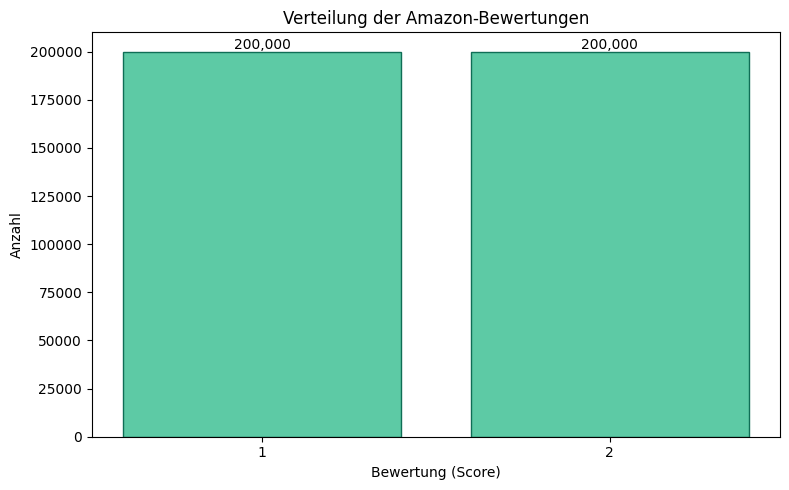

In [9]:
import matplotlib.pyplot as plt

score_pd = score_dist.toPandas()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    score_pd["Score"].astype(str),
    score_pd["Anzahl"],
    color="#5DCAA5",
    edgecolor="#0F6E56"
)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.xlabel("Bewertung (Score)")
plt.ylabel("Anzahl")
plt.title("Verteilung der Amazon-Bewertungen")
plt.tight_layout()
plt.show()

### Erkenntnis: Perfekte Balance

**200.000 negative und 200.000 positive Bewertungen — exakt 50/50.**

Das ist ideal für Machine Learning. In der Praxis sind Datensätze selten so
perfekt balanciert. Hier hat Kaggle die Daten bereits für uns vorbereitet.
Das bedeutet: Unser Modell wird nicht dazu neigen, eine Klasse zu bevorzugen.

## 1.5 Duplikate prüfen

In [10]:
total = df_raw.count()
distinct = df_raw.dropDuplicates().count()
duplicates = total - distinct

print(f"Gesamtzeilen:      {total:>10,}")
print(f"Eindeutige Zeilen: {distinct:>10,}")
print(f"Duplikate:         {duplicates:>10,}")

Gesamtzeilen:         400,000
Eindeutige Zeilen:    400,000
Duplikate:                  0


## 1.6 Wie lang sind die Texte?

Für die spätere NLP-Verarbeitung ist die Textlänge wichtig.
Sehr kurze Texte enthalten wenig Information; sehr lange Texte
verlangsamen die Verarbeitung.

In [11]:
from pyspark.sql.functions import length, avg, min as spark_min, max as spark_max

df_with_len = df_raw.withColumn("text_length", length(col("Text")))

df_with_len.select(
    spark_min("text_length").alias("Min"),
    spark_round(avg("text_length"), 0).alias("Durchschnitt"),
    spark_max("text_length").alias("Max")
).show()

+---+------------+----+
|Min|Durchschnitt| Max|
+---+------------+----+
| 15|       405.0|1009|
+---+------------+----+



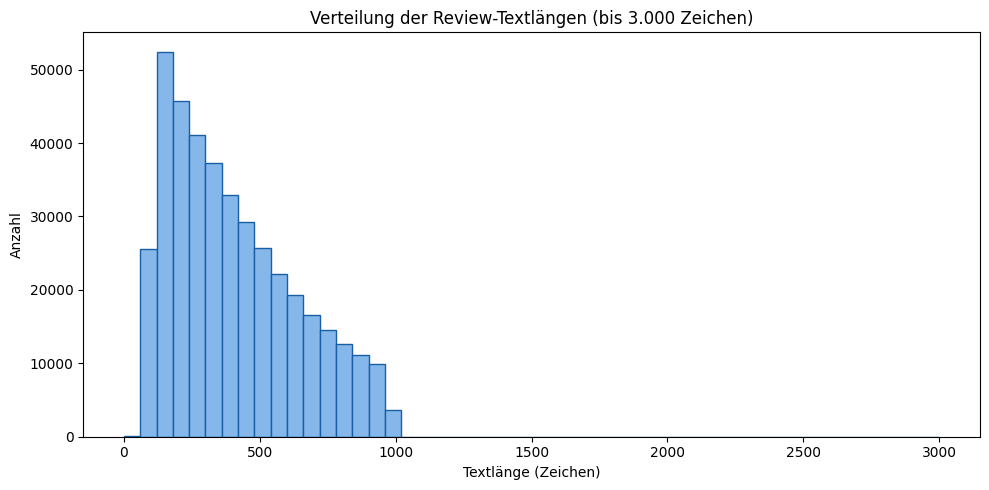

In [12]:
text_len_pd = df_with_len.select("text_length").toPandas()

plt.figure(figsize=(10, 5))
plt.hist(text_len_pd["text_length"].dropna(), bins=50, color="#85B7EB", edgecolor="#185FA5", range=(0, 3000))
plt.xlabel("Textlänge (Zeichen)")
plt.ylabel("Anzahl")
plt.title("Verteilung der Review-Textlängen (bis 3.000 Zeichen)")
plt.tight_layout()
plt.show()

## Kapitel 1 — Zusammenfassung

| Was wir gelernt haben | Detail |
|----------------------|--------|
| Datensatzgröße | 400.000 Bewertungen |
| Spalten | Score (Label), Summary, Text |
| Balance | Perfekt: 200K negativ, 200K positiv |
| Datenqualität | Nur 4 fehlende Werte, 0 Duplikate |
| Textlänge | Mehrheitlich zwischen 50 und 1.000 Zeichen |

**Die Daten sehen vielversprechend aus.** Wir haben einen großen, balancierten Datensatz
mit minimalen Qualitätsproblemen.

**Nächstes Kapitel:** Wir bereinigen die Daten — fehlende Werte entfernen, Text normalisieren
und alles für die maschinelle Verarbeitung vorbereiten.